# 1. Librairies

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import math

# Affiche toutes les lignes
pd.set_option('display.max_rows', None)

# Affiche toutes les colonnes
pd.set_option('display.max_columns', None)
# Choisis le nombre de caractère par colonnes
pd.set_option('display.max_colwidth', 50)

In [120]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


# 2. Fonctions de visualisation

In [121]:
def first_overview(df):
    print(f'Shape of dataset : {df.shape}\n')
    print(f'Number of duplicate : {df.duplicated().sum()}\n')
    if df.shape[1] < 20:
        print(f'Variable types : \n{df.dtypes}\n')
    else:
        print(f'Variable types : \n{df.dtypes.value_counts()}\n')
    display(df.head(2))
    display(df.describe().T)
    try:
        display(df.describe(include=('object', 'str')).T)
    except:
        pass
    return 

In [122]:
def missing_val_overview(df, all_col=True):

    if all_col==True:
        info_col = df.columns
    else:
        info_col = df.columns[df.isna().any()]

    missing_table = pd.DataFrame({'Number': df[info_col].isna().sum(), 'Ratio': np.round(df[info_col].isna().sum()/df[info_col].shape[0]*100, 2)})
    missing_table = missing_table.sort_values(by='Ratio',ascending=False)
    print(f'Missing values : \n{missing_table}\n')
    
    plt.figure(figsize=(20, 5))
    sns.heatmap(df[info_col].isna(), cbar=False)
    plt.title('NaN values visualisation')
    plt.show()

In [123]:
def proportion_visualisation(df, num_col):
    # Number of columns and rows
    n = len(num_col)
    cols = 4
    rows = math.ceil(n / cols)
    # Main fig - size
    fig = plt.figure(figsize=(6*cols, 5*rows))
    # Sub fig - number
    outer = fig.add_gridspec(rows, cols)
    #
    for i, col in enumerate(num_col):
        # Fig location
        c = i % cols
        r = i // cols
        # Sub fig - parameters
        inner = outer[r, c].subgridspec(2, 1, height_ratios=[0.85, 0.15])
        # Add axis
        ax1 = fig.add_subplot(inner[0])
        ax2 = fig.add_subplot(inner[1])
        # first graph
        sns.histplot(df[col], ax=ax1)
        ax1.set_xlabel('')
        ax1.set_ylabel('Count')
        ax1.set_title(f'| {col} | - Histplot and Boxplot')
        # Second graph
        sns.boxplot(x=df[col], ax=ax2)
        ax2.set_xlabel('')
        ax2.set_ylabel('')
    #
    plt.tight_layout()
    plt.show()

# 3. Téléchargement du dataset

In [124]:
data_path = 'healthcare_fraud_detection.csv'

data_raw = pd.read_csv(data_path)

In [125]:
df = data_raw.copy()

# 4. Visualisation des données

### 4.a Structure et valeurs manquantes

In [126]:
first_overview(df)

Shape of dataset : (10000, 20)

Number of duplicate : 0

Variable types : 
str        10
int64       7
float64     3
Name: count, dtype: int64



,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0


,count,mean,std,min,25%,50%,75%,max
Patient_Age,10000.0,49.755000,17.910144,1.00,37.750,50.000,62.0000,95.00
Procedure_Code,10000.0,86905.211700,14965.324960,36415.00,80053.000,93000.000,99213.0000,99214.00
Claim_Amount,10000.0,572.804406,406.202437,60.21,305.205,461.225,711.3650,6590.70
Approved_Amount,10000.0,475.514157,323.257165,50.35,257.200,388.370,598.3475,4270.89
Days_Between_Service_and_Claim,10000.0,14.413800,8.489875,0.00,7.000,14.000,22.0000,29.00
Number_of_Claims_Per_Provider_Monthly,10000.0,68.628000,14.905872,42.00,60.000,66.000,72.0000,144.00
Is_Fraud,10000.0,0.082900,0.275745,0.00,0.000,0.000,0.0000,1.00
Length_of_Stay,10000.0,2.199300,1.710460,0.00,1.000,2.000,3.0000,5.00
Chronic_Condition_Flag,10000.0,0.292000,0.454705,0.00,0.000,0.000,1.0000,1.00
Prior_Visits_12m,9650.0,3.026425,1.722789,0.00,2.000,3.000,4.0000,12.00


,count,unique,top,freq
Provider_ID,10000,300,P0142,52
Claim_ID,10000,10000,C0000000,1
Patient_Gender,10000,2,Female,5001
Diagnosis_Code,10000,10,M54.5,1055
Insurance_Type,9650,4,Medicare,2425
Claim_Submission_Date,10000,1476,2023-09-11,21
Provider_Specialty,9650,6,Internal Medicine,2019
Patient_State,10000,8,PA,1327
Claim_Status,10000,3,Approved,7053
Visit_Type,10000,3,Outpatient,3423


Missing values : 
                                       Number  Ratio
Provider_Specialty                        350    3.5
Prior_Visits_12m                          350    3.5
Insurance_Type                            350    3.5
Provider_ID                                 0    0.0
Patient_Gender                              0    0.0
Patient_Age                                 0    0.0
Claim_ID                                    0    0.0
Diagnosis_Code                              0    0.0
Approved_Amount                             0    0.0
Claim_Submission_Date                       0    0.0
Claim_Amount                                0    0.0
Procedure_Code                              0    0.0
Number_of_Claims_Per_Provider_Monthly       0    0.0
Days_Between_Service_and_Claim              0    0.0
Claim_Status                                0    0.0
Patient_State                               0    0.0
Is_Fraud                                    0    0.0
Length_of_Stay              

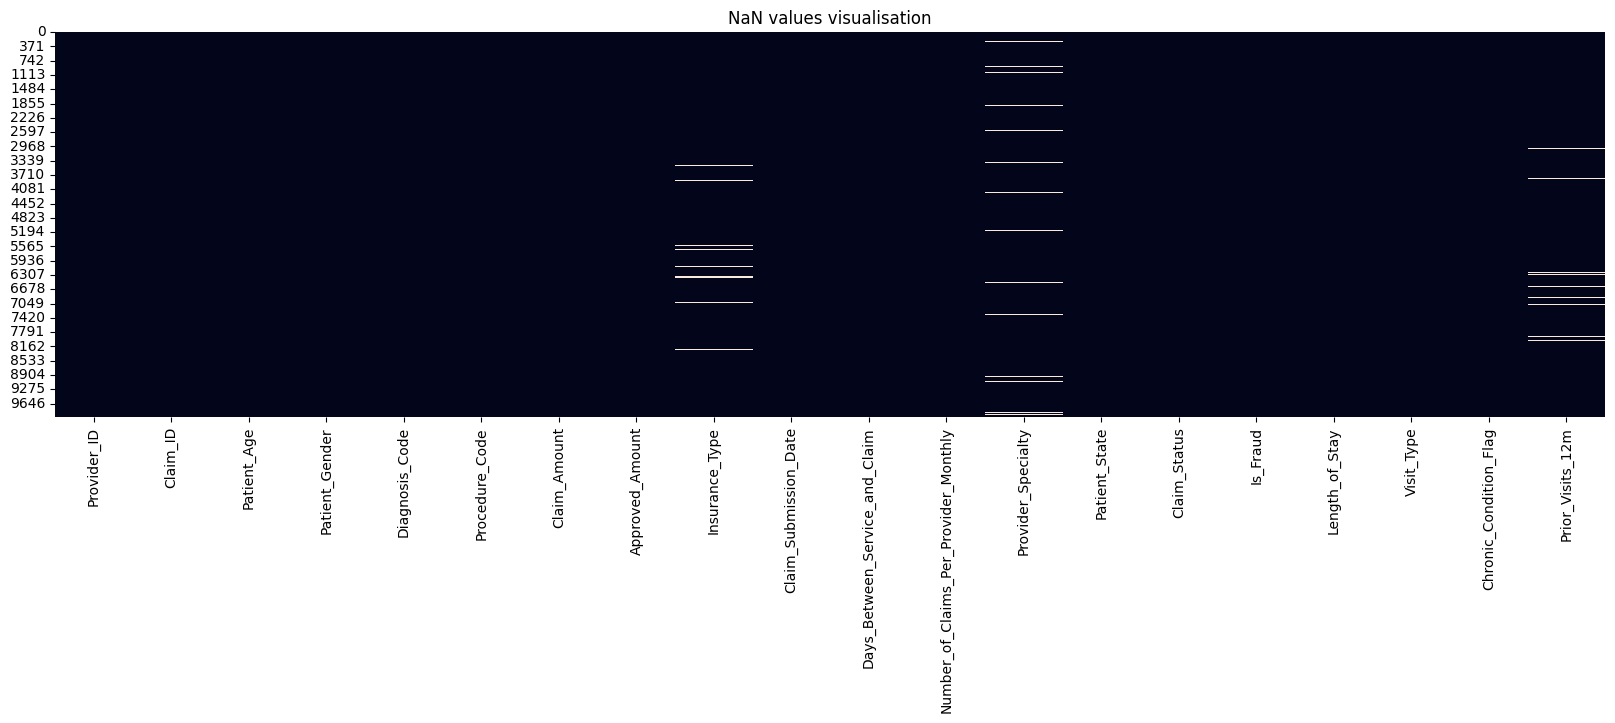

In [127]:
missing_val_overview(df)

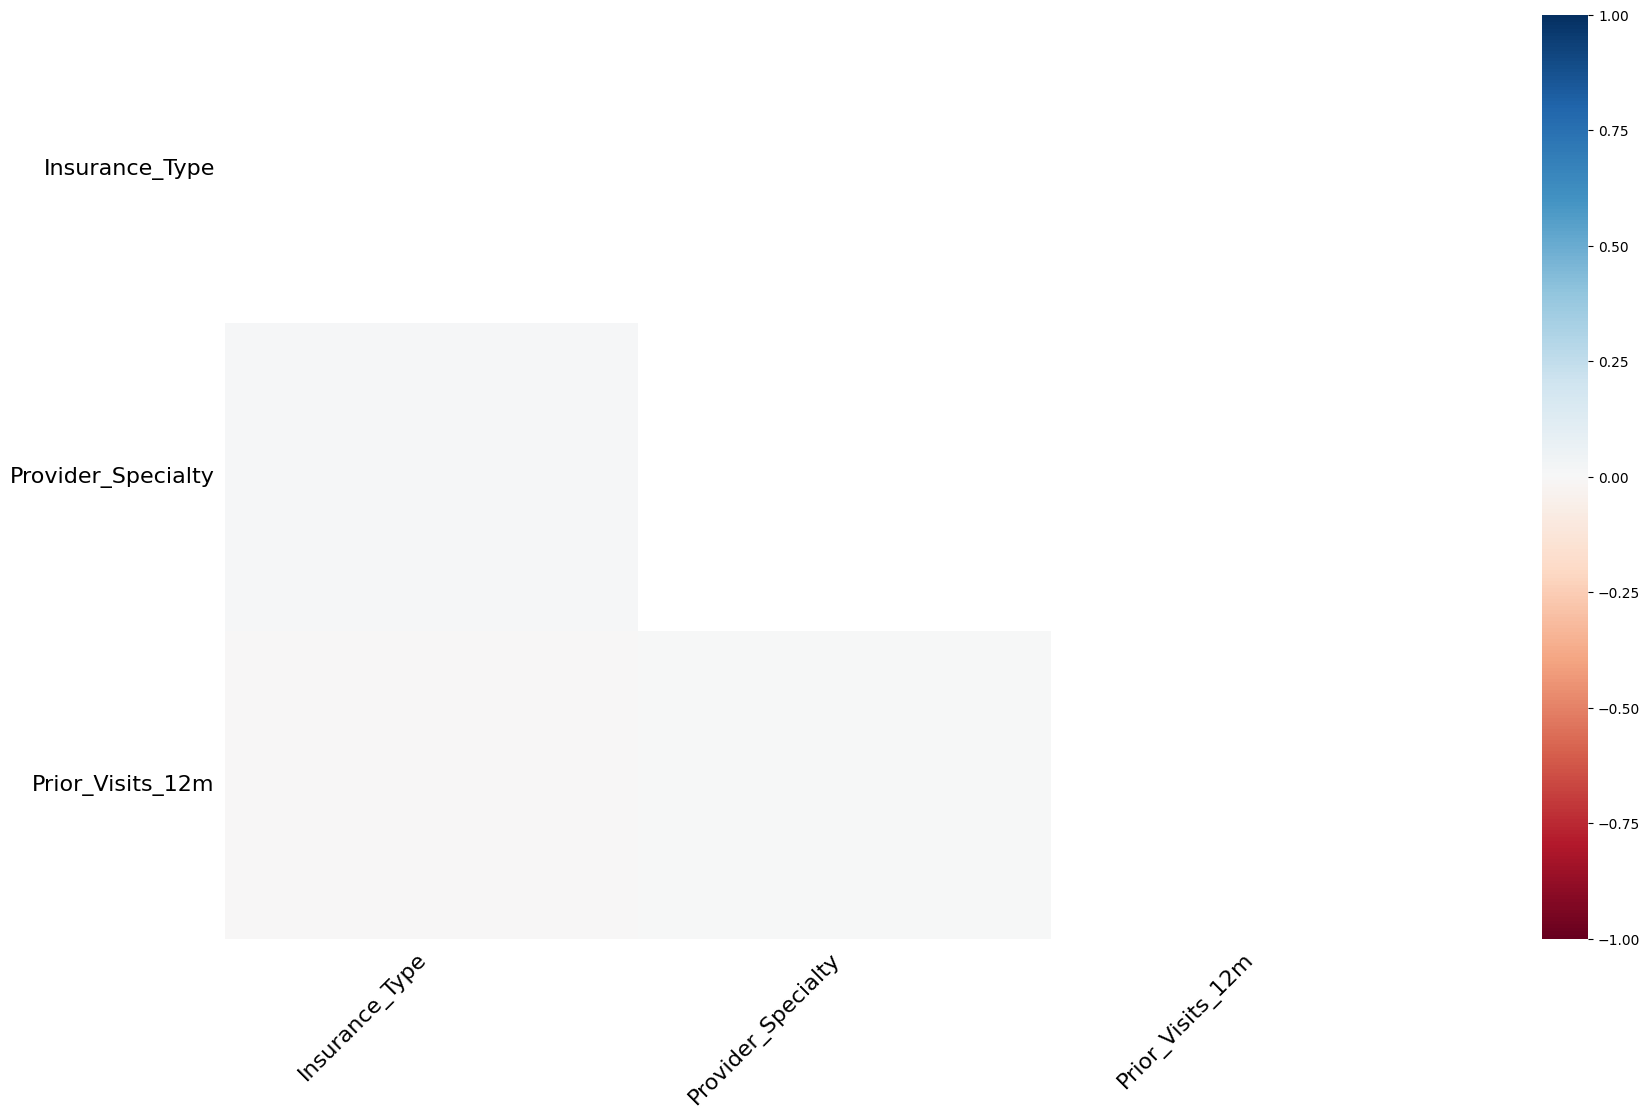

In [128]:
msno.heatmap(df)
plt.show()

### 4.b Visualisation des proportions

In [129]:
target = 'Is_Fraud'
#
num_col = list(df.select_dtypes(include=['int', 'float']).columns.drop(target))
str_col = list(df.select_dtypes(include=['str']).columns)
cat_col = []

for col in str_col:
    if df[col].nunique() <= 10:
        cat_col.append(col)

In [130]:
print(df[target].value_counts())

Is_Fraud
0    9171
1     829
Name: count, dtype: int64


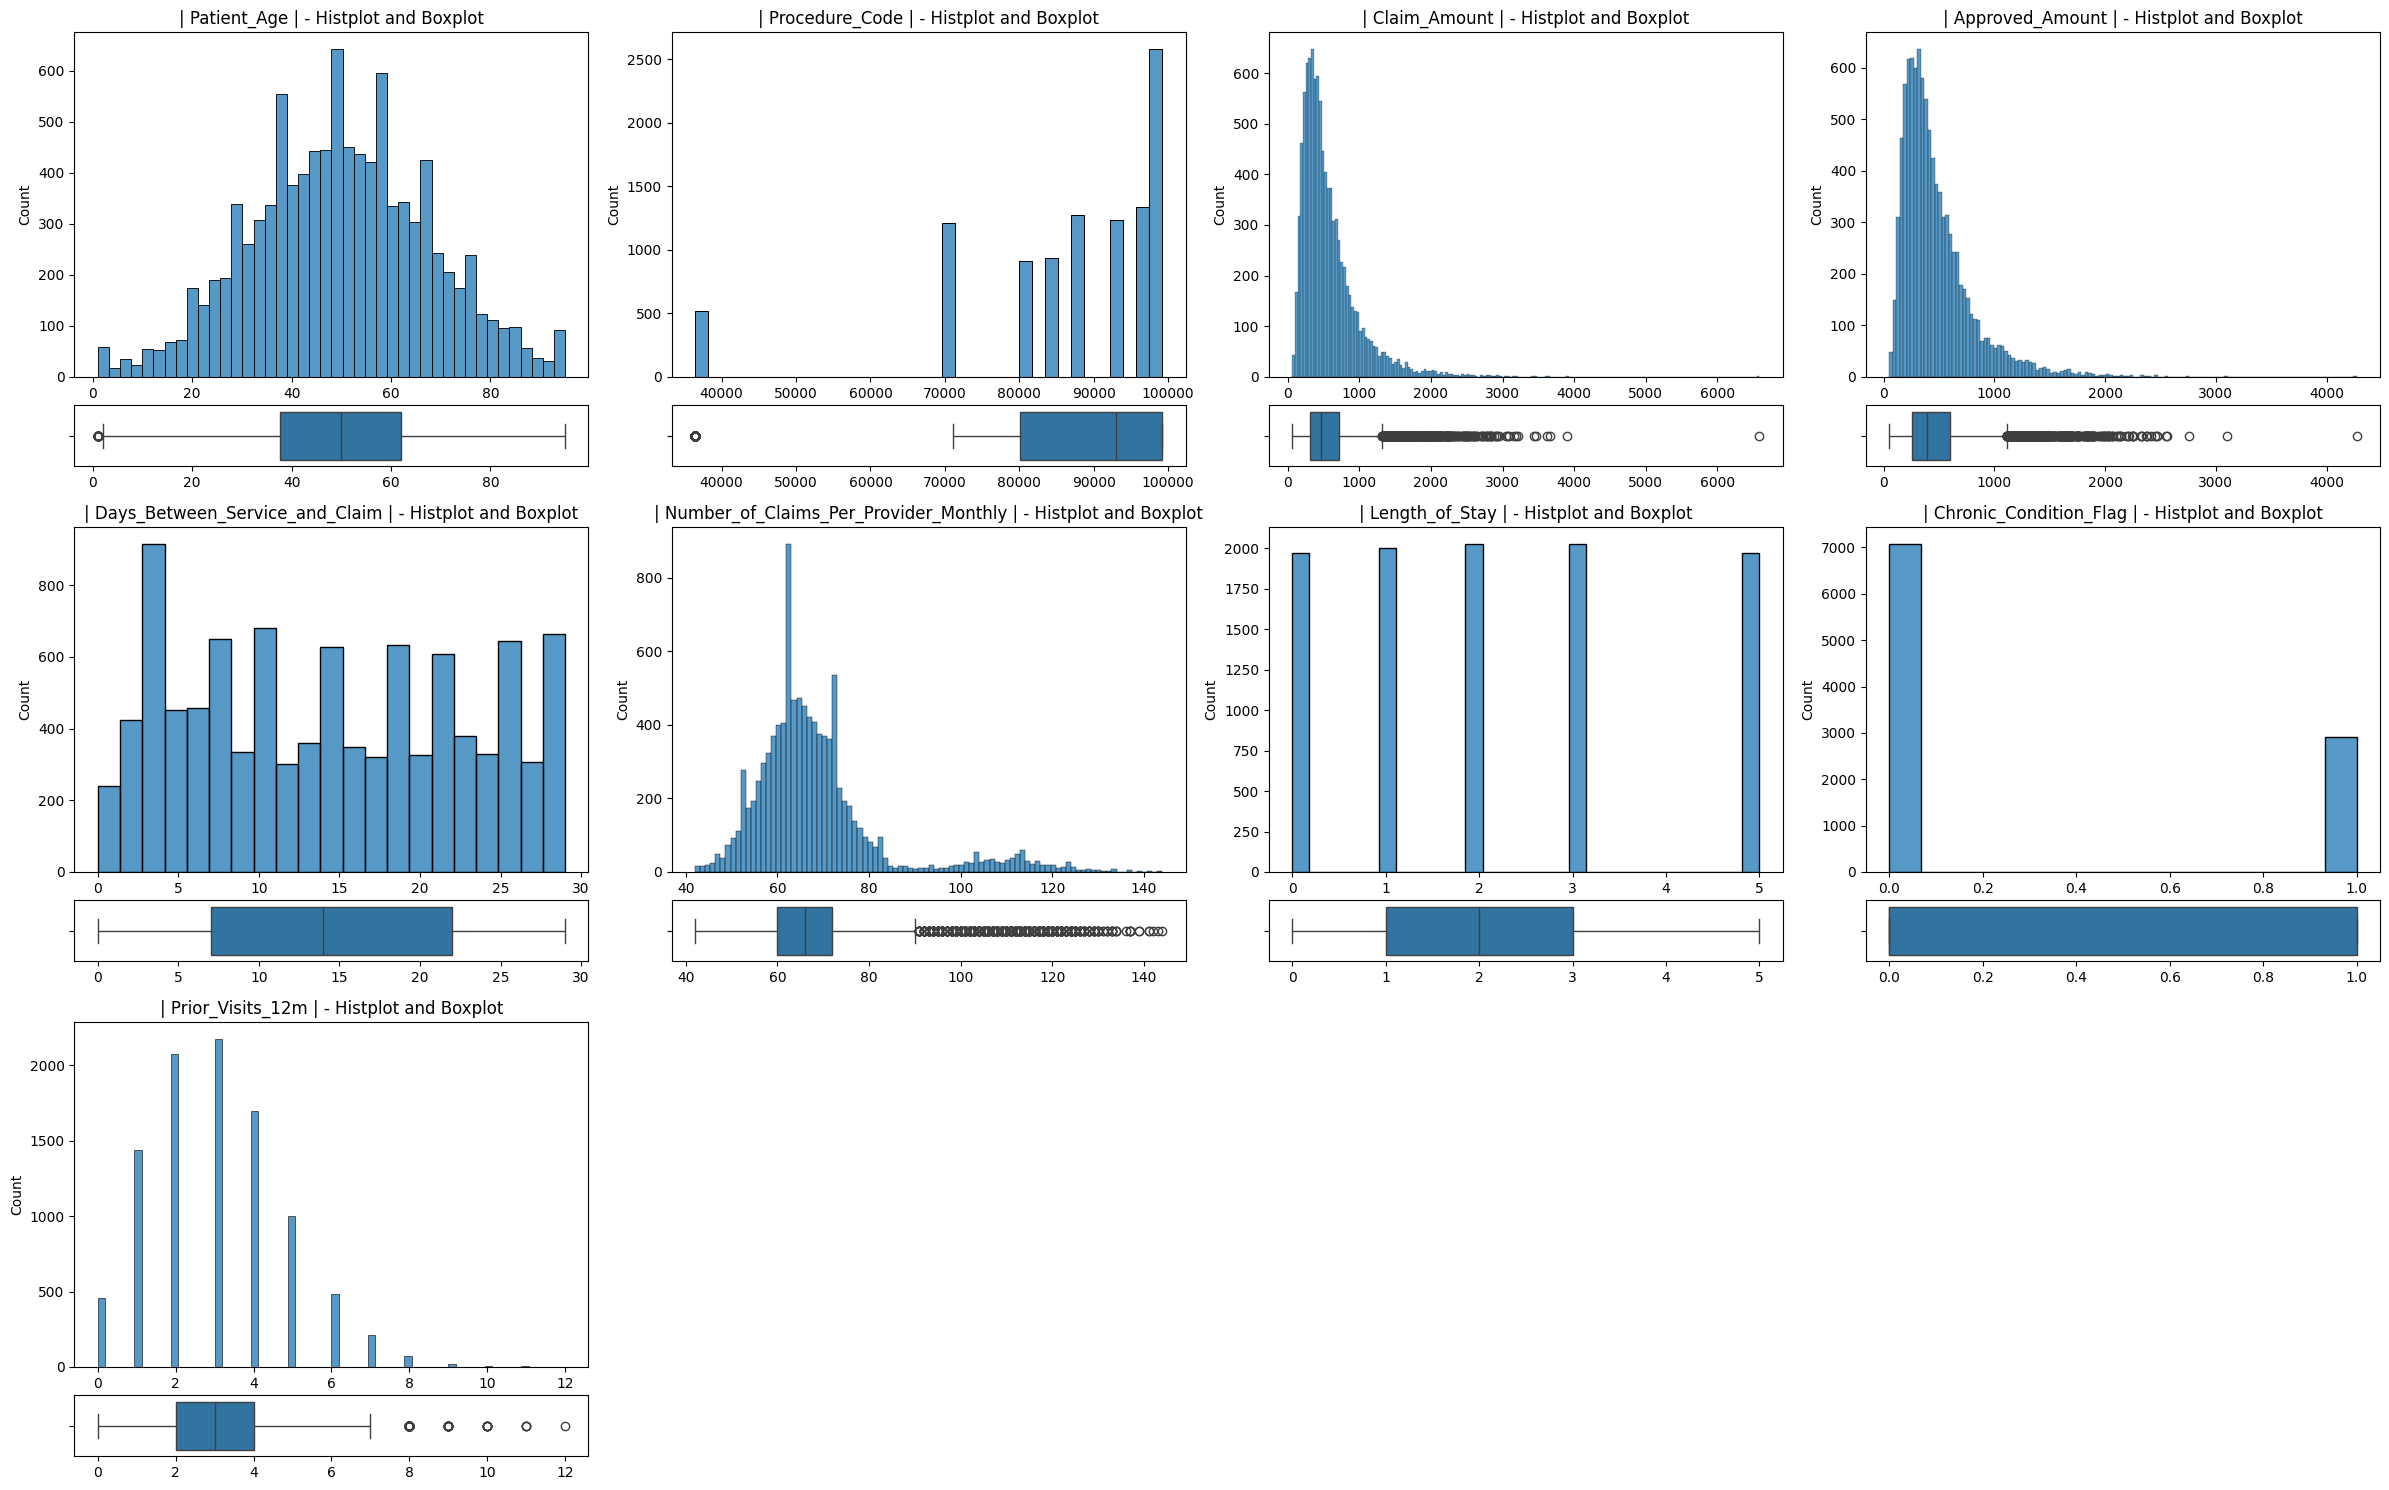

In [131]:
proportion_visualisation(df, num_col)

Provider_Specialty
Internal Medicine    2019
General Practice     1878
Orthopedics          1616
Neurology            1516
Cardiology           1366
Pulmonology          1255
Name: count, dtype: int64


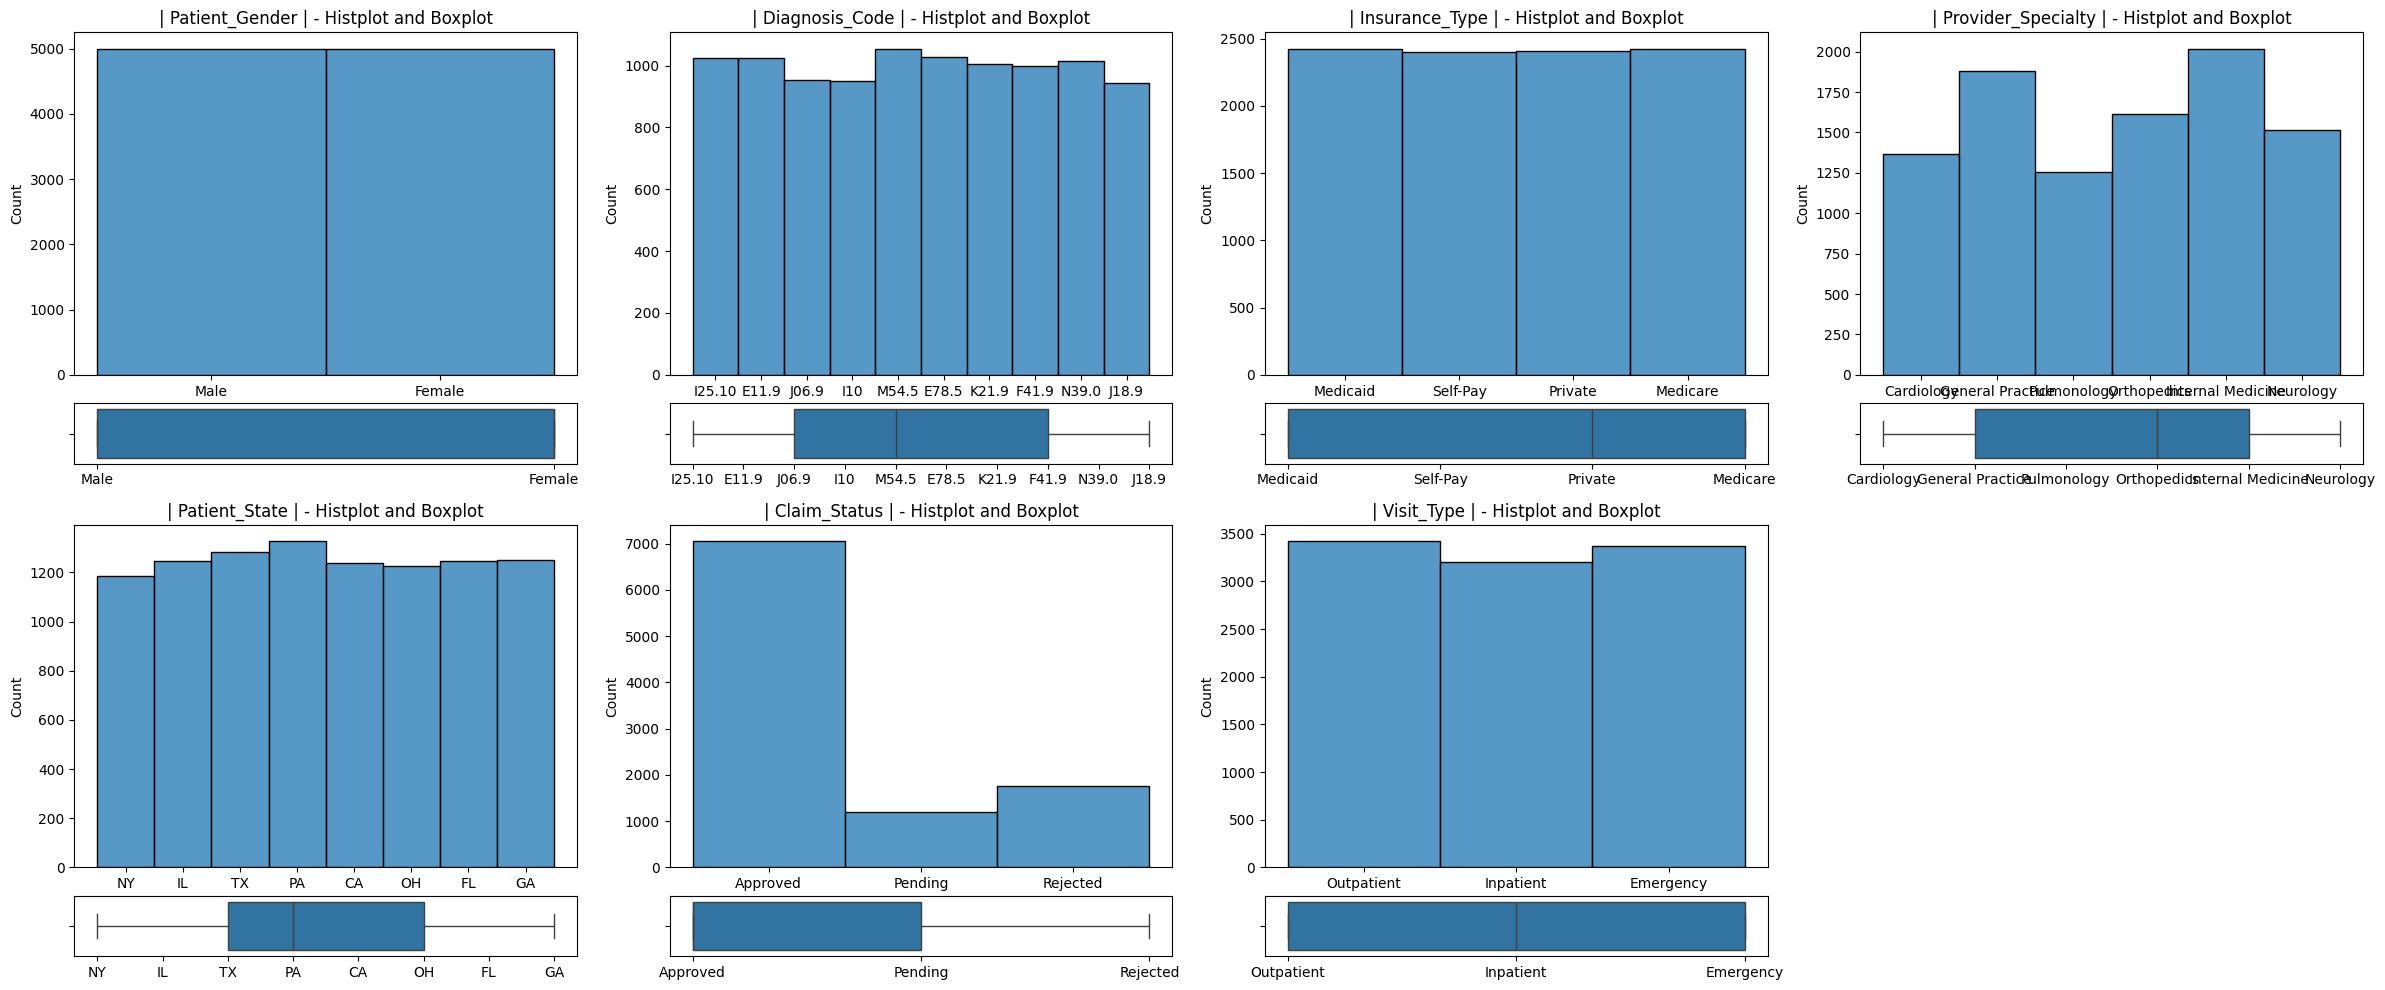

In [132]:
print(df['Provider_Specialty'].value_counts())

proportion_visualisation(df, cat_col)

In [133]:
print('Plus grandes récurrances :')
print(f'{df["Provider_ID"].value_counts().head()}')
print('\nRécurrance :')
print(f'Médiane = {df["Provider_ID"].value_counts().median()}')
print(f'Ecart type = {df["Provider_ID"].value_counts().std()}')
print(f'Maximum = {df["Provider_ID"].value_counts().max()}')
print(f'Minimum = {df["Provider_ID"].value_counts().min()}')

Plus grandes récurrances :
Provider_ID
P0142    52
P0113    51
P0050    50
P0199    48
P0205    48
Name: count, dtype: int64

Récurrance :
Médiane = 33.0
Ecart type = 5.850039781091813
Maximum = 52
Minimum = 18


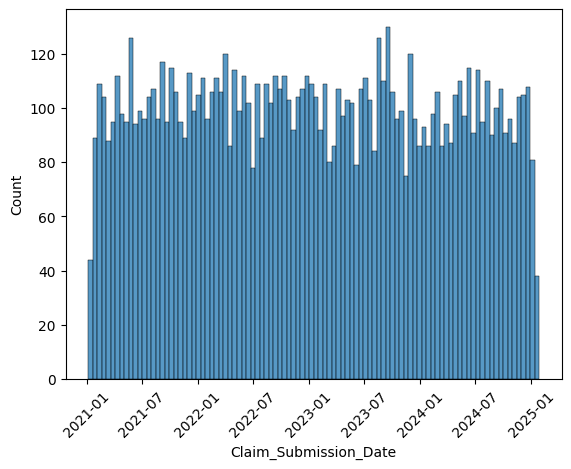

In [134]:
df['Claim_Submission_Date'] = pd.to_datetime(df['Claim_Submission_Date'])

sns.histplot(df['Claim_Submission_Date'], bins=100)
plt.xticks(rotation=45)
plt.show()

# 5. Preprocessing
L'objectif est surtout de travailler la classification avec PyTorch.   
Nous allons donc faire un preprocessing très basique.

### 5.a Suppression des valeurs manquantes et des colonnes inutiles

In [135]:
df = df.dropna()

In [136]:
# 'Claim_ID' ne donne pas d'information
# 'Provider_ID' et 'Claim_Submission_Date' ne vont pas être inclus pour simplifier le dataset
df = df.drop(columns=['Claim_ID', 'Provider_ID', 'Claim_Submission_Date'])

### 5.b Normalisation des variables numériques (non catégorielles)

In [137]:
from sklearn.preprocessing import RobustScaler

scale_col = ['Patient_Age', 'Procedure_Code', 'Claim_Amount', 'Approved_Amount', 'Days_Between_Service_and_Claim', 'Number_of_Claims_Per_Provider_Monthly', 'Prior_Visits_12m']

robust_scaler = RobustScaler()
df[scale_col] = robust_scaler.fit_transform(df[scale_col])

### 5.c Encodage des variables non numériques

In [138]:
binary_map = {
    'Female': 1, 'Male': 0,
    'Approved': 2, 'Pending': 1, 'Rejected': 0
}

ordinal_col = ['Patient_Gender', 'Claim_Status']

for col in ordinal_col:
    df[col] = df[col].replace(binary_map)
    df[col] = df[col].astype(int)

In [139]:
from sklearn.preprocessing import OneHotEncoder

one_hot_col = ['Diagnosis_Code', 'Insurance_Type', 'Provider_Specialty', 'Patient_State', 'Visit_Type']

encoder_one_hot = OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=0.02, sparse_output=False)
encoded_data = encoder_one_hot.fit_transform(df[one_hot_col])
encoded_df = pd.DataFrame(encoded_data, columns=encoder_one_hot.get_feature_names_out(one_hot_col), index=df.index)
df = pd.concat([df, encoded_df], axis=1).drop(one_hot_col, axis=1)

# 6. Segmentation des données

In [140]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size = 0.5)

print("Données d'entrainement: ", X_train.shape[0], " qui représente ", round(X_train.shape[0]/df.shape[0],4)*100, "%") 
print("Données de validation: ",X_val.shape[0], " qui représente ", round(X_val.shape[0]/df.shape[0],4)*100, "%") 
print("Données de test: ",X_test.shape[0], " qui représente ", round(X_test.shape[0]/df.shape[0],4)*100, "%")
     

Données d'entrainement:  6292  qui représente  70.0 %
Données de validation:  1349  qui représente  15.010000000000002 %
Données de test:  1348  qui représente  15.0 %


# 7. Dataset object (redéfinir certaines fonctions)

In [141]:
class dataset(Dataset):
    # Convertis les données en tenseurs puis les envois au device
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32).to(device)
        self.y = torch.tensor(y.values, dtype=torch.float32).to(device)

    # Récupération de la taille du jeu de données
    def __len__(self):
        return len(self.X)

    # Récupération du lot voulut dans le jeu de données
    def __getitem__(self, index):
        return self.X[index], self.y[index]
    
# Création des 3 ensembles
train_data = dataset(X_train, y_train)
test_data = dataset(X_test, y_test)
val_data = dataset(X_val, y_val)

# 8. Choix des hyper paramètres

In [142]:
BATCH_SIZE = 32
HIDDEN_NEURONS = 50
LR = 1e-3
EPOCHS = 15

# 9. Data loaders

In [143]:
# Ajout du nombre de lot par itération
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=True)

# 10. Model class (redéfinir certaines fonctions)

In [144]:
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()

        # Couche d'entrée
        self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
        # Couches cachées
        self.hidden_layer_1 = nn.Linear(HIDDEN_NEURONS, HIDDEN_NEURONS)
        # Couche de sortie
        self.output_layer = nn.Linear(HIDDEN_NEURONS, 1)
        # Convertit la valeur de sortie en probabilité
        self.sigmoid = nn.Sigmoid()

        # Ajout d'une activation non-linéaire
        self.relu = nn.ReLU()

    # Flux des données
    def forward(self, x):
        x = self.input_layer(x)
        x = self.relu(x)
        x = self.hidden_layer_1(x)
        x = self.relu(x)
        x = self.output_layer(x)
        x = self.sigmoid(x)
        return x

# 11. Création du model

In [145]:
# Instance du modèle
model = MyModel().to(device)
# Résumé du modèle
summary(model, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 50]           2,150
              ReLU-2                   [-1, 50]               0
            Linear-3                   [-1, 50]           2,550
              ReLU-4                   [-1, 50]               0
            Linear-5                    [-1, 1]              51
           Sigmoid-6                    [-1, 1]               0
Total params: 4,751
Trainable params: 4,751
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.02
Estimated Total Size (MB): 0.02
----------------------------------------------------------------


# 12. Loss et Optimizer

In [146]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr = LR)

# 13. Entrainement des données

In [147]:
total_loss_train_plot = []
total_loss_val_plot = []
total_acc_train_plot = []
total_acc_val_plot = []

# Nombre d'itération sur l'ensemble du jeu de données
for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0
    
    # Entrainement du modèle (train_data)
    for data in train_dataloader:
        inputs, labels = data
        
        prediction = model(inputs).squeeze(1)

        batch_loss = criterion(prediction, labels)

        total_loss_train += batch_loss.item()

        acc = ((prediction).round() == labels).sum().item()

        total_acc_train += acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    # Validation du modèle (val_data)
    with torch.no_grad():
        for data in val_dataloader:
            inputs, labels = data

            prediction = model(inputs).squeeze(1)

            batch_loss = criterion(prediction, labels)

            total_loss_val += batch_loss.item()

            acc = ((prediction).round() == labels).sum().item()

            total_acc_val += acc
    
    # Visualisation de l'entrainement
    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_loss_val_plot.append(round(total_loss_val/1000, 4))

    total_acc_train_plot.append(round(total_acc_train/train_data.__len__()*100, 4))
    total_acc_val_plot.append(round(total_acc_val/val_data.__len__()*100, 4))

    print(f'''Epoch no. {epoch+1} Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy: {round(total_acc_train/train_data.__len__()*100, 4)} 
              Validation Loss: {round(total_loss_val/1000, 4)} Validation Accuracy: {round(total_acc_val/val_data.__len__()*100, 4)} ''')
    print('='*25)

Epoch no. 1 Train Loss: 0.0496 Train Accuracy: 92.2123 
              Validation Loss: 0.0054 Validation Accuracy: 95.0334 
Epoch no. 2 Train Loss: 0.0161 Train Accuracy: 97.2187 
              Validation Loss: 0.0026 Validation Accuracy: 97.4796 
Epoch no. 3 Train Loss: 0.0097 Train Accuracy: 98.2517 
              Validation Loss: 0.002 Validation Accuracy: 97.9244 
Epoch no. 4 Train Loss: 0.0074 Train Accuracy: 98.7921 
              Validation Loss: 0.0016 Validation Accuracy: 98.6657 
Epoch no. 5 Train Loss: 0.0059 Train Accuracy: 98.9828 
              Validation Loss: 0.0019 Validation Accuracy: 98.4433 
Epoch no. 6 Train Loss: 0.0055 Train Accuracy: 99.0623 
              Validation Loss: 0.0014 Validation Accuracy: 98.8881 
Epoch no. 7 Train Loss: 0.0047 Train Accuracy: 99.2689 
              Validation Loss: 0.0014 Validation Accuracy: 98.5174 
Epoch no. 8 Train Loss: 0.0044 Train Accuracy: 99.2371 
              Validation Loss: 0.0016 Validation Accuracy: 98.7398 
Epoch no.

# 14. Test du modèle

In [148]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0

    for data in test_dataloader:
        inputs, labels = data

        prediction = model(inputs).squeeze(1)

        batch_loss = criterion(prediction, labels)

        total_loss_test += batch_loss.item()

        acc = ((prediction).round() == labels).sum().item()

        total_acc_test += acc

print(f'Accuracy {round(total_acc_test/test_data.__len__()*100, 4)}')

Accuracy 98.5163


# 15. Visualisation de l'entrainement

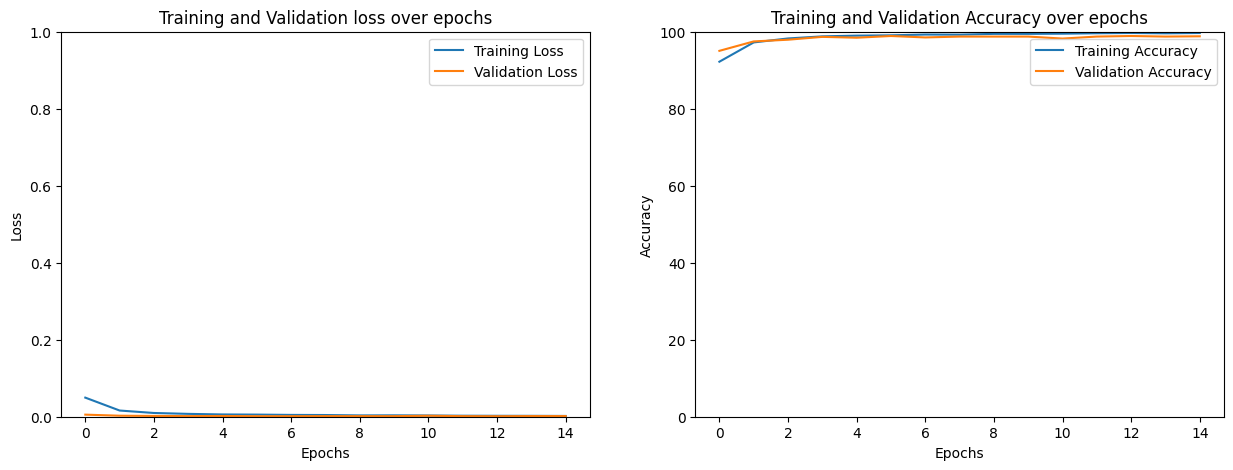

In [149]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

ax[0].plot(total_loss_train_plot, label='Training Loss')
ax[0].plot(total_loss_val_plot, label='Validation Loss')
ax[0].set_title('Training and Validation loss over epochs')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_ylim([0, 1])
ax[0].legend()

ax[1].plot(total_acc_train_plot, label='Training Accuracy')
ax[1].plot(total_acc_val_plot, label='Validation Accuracy')
ax[1].set_title('Training and Validation Accuracy over epochs')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim([0, 100])
ax[1].legend()

# 16. Fonction de prédiction

In [150]:
def predict_fraud(data, scale_col, ordinal_col, one_hot_col, feature_col, scaler, encoder):
    binary_map = {
    'Female': 1, 'Male': 0,
    'Approved': 2, 'Pending': 1, 'Rejected': 0
    }
    #
    for col in ordinal_col:
        data[col] = data[col].replace(binary_map)
        data[col] = data[col].astype(int)
    #
    #
    data[scale_col] = scaler.transform(data[scale_col])
    #
    #
    encoded_data_2 = encoder.transform(data[one_hot_col])
    encoded_df_2 = pd.DataFrame(encoded_data_2, columns=encoder.get_feature_names_out(one_hot_col), index=data.index)
    data = pd.concat([data, encoded_df_2], axis=1).drop(one_hot_col, axis=1)
    #
    #
    #
    #
    input_values = data[feature_col].values
    #
    model_inputs = torch.Tensor(input_values).to(device)
    prediction = (model(model_inputs))
    print(f'Probabilité de la prédiction: {round(prediction.item(), 3)}')
    print('='*5)
    if prediction.item() >= 0.7:
        print("Possibilté de fraude: élevé")
    elif 0.7 > prediction.item() >= 0.5:
        print("Possibilté de fraude: moyenne")
    elif 0.5 > prediction.item() >= 0.2:
        print("Possibilté de fraude: faible")
    else:
        print("Possibilté de fraude: très faible")

### 16.a Création d'un données a prédire (valeurs aléatoires)

In [151]:
df_random = pd.DataFrame(columns=data_raw.columns)

for col in data_raw.columns:
    if pd.api.types.is_numeric_dtype(data_raw[col]):
        min_val = data_raw[col].min()
        max_val = data_raw[col].max()
        # Valeur aléatoire dans l'intervalle du jeu d'entrainement
        df_random[col] = np.random.uniform(min_val, max_val, size=1)
    else:
        values = data_raw[col].dropna().unique()
        # Valeur aléatoire dans l'intervalle du jeu d'entrainement
        if len(values) > 0:
            df_random[col] = np.random.choice(values, size=1)
        else:
            df_random[col] = None 

display(df_random)

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0091,C0002950,35.425069,Female,K21.9,72092.476689,3890.947203,1926.046341,Self-Pay,2023-04-20,1.919639,136.018395,Internal Medicine,NY,Approved,0.372622,3.50521,Outpatient,0.095857,0.87186


### 16.b Prédiction de la fraude

In [152]:
feature_col = X.columns

predict_fraud(df_random, scale_col, ordinal_col, one_hot_col, feature_col, robust_scaler, encoder_one_hot)

Probabilité de la prédiction: 1.0
=====
Possibilté de fraude: élevé
